In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_skill = pd.read_csv(r"d:\Startup\Project\ai-career-coach\data\processed\jobs_with_skills.csv")
df_jobs = pd.read_csv(r"d:\Startup\Project\ai-career-coach\data\processed\jobs_cleaned.csv")
df_salary = pd.read_csv(r"d:\Startup\Project\ai-career-coach\data\processed\salary_jobs.csv")

Geographic Analysis

In [3]:
location_counts = df_skill["Location"].value_counts() 
valid_locations = location_counts[location_counts >= 3].index 
df_skill = df_skill[df_skill["Location"].isin(valid_locations)]

In [23]:
valid_locations

Index(['Remote', 'Bangalore', 'Delhi', 'Gurgaon', 'Noida'], dtype='object', name='Location')

In [4]:
df_skill.Location

0         Remote
1         Remote
2         Remote
3         Remote
4         Remote
         ...    
158    Hyderabad
159       Remote
161       Remote
162    Bangalore
163       Remote
Name: Location, Length: 151, dtype: object

In [5]:
location_demand = df_skill["Location"].value_counts().reset_index()
location_demand.columns = ["Location", "Job_Count"]

location_demand["Percentage"] = (
    location_demand["Job_Count"] / len(df_skill) * 100
)

In [24]:
location_demand

,Location,Job_Count,Percentage
0,Remote,81,53.642384
1,Bangalore,31,20.529801
2,Maharashtra,11,7.284768
3,Hyderabad,7,4.635762
4,Delhi,6,3.973510
5,Gurgaon,4,2.649007
6,Noida,4,2.649007
7,Chennai,4,2.649007
8,Ahmedabad,3,1.986755


In [7]:
location_role = (
    df_skill.groupby(["Location", "Standardized_Job_Title"])
    .size()
    .reset_index(name="Count")
)


In [8]:
location_role

,Location,Standardized_Job_Title,Count
0,Ahmedabad,Data Analyst,1
1,Ahmedabad,Data Engineer,1
2,Ahmedabad,Data Scientist,1
3,Bangalore,Analytics,6
4,Bangalore,Business Analyst,3
5,Bangalore,Data Analyst,3
6,Bangalore,Data Engineer,6
7,Bangalore,Data Scientist,6
8,Bangalore,Machine Learning Engineer,3
9,Bangalore,Other,2


In [9]:
location_role.pivot_table(
    index = 'Location',
    columns = 'Standardized_Job_Title',
    values = 'Count'
).fillna(0)


Standardized_Job_Title,Analytics,Business Analyst,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Other,Product Analyst
Location,,,,,,,,
Ahmedabad,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
Bangalore,6.0,3.0,3.0,6.0,6.0,3.0,2.0,2.0
Chennai,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0
Delhi,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
Gurgaon,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0
Hyderabad,0.0,0.0,3.0,2.0,0.0,1.0,1.0,0.0
Maharashtra,0.0,0.0,1.0,2.0,3.0,2.0,2.0,1.0
Noida,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
Remote,8.0,4.0,39.0,12.0,5.0,3.0,9.0,1.0


In [10]:
remote_stats = df_skill.groupby("Location").size().sort_values(ascending= False) 
remote_ratio = df_skill["Location"].value_counts(normalize=True) * 100

In [11]:
remote_stats

Location
Remote         81
Bangalore      31
Maharashtra    11
Hyderabad       7
Delhi           6
Gurgaon         4
Chennai         4
Noida           4
Ahmedabad       3
dtype: int64

In [12]:
remote_ratio

Location
Remote         53.642384
Bangalore      20.529801
Maharashtra     7.284768
Hyderabad       4.635762
Delhi           3.973510
Gurgaon         2.649007
Noida           2.649007
Chennai         2.649007
Ahmedabad       1.986755
Name: proportion, dtype: float64

Location VS Salary Analysis

In [13]:
salary_counts = df_salary["Location"].value_counts() 
valid_locations = salary_counts[salary_counts >= 3].index 
df_salary = df_salary[df_salary["Location"].isin(valid_locations)]

In [14]:
location_salary = (df_salary.groupby("Location")["salary_avg"] 
                        .median() .reset_index().sort_values(by = 'salary_avg' ,ascending=False) )
location_salary


,Location,salary_avg
3,Noida,2850000.0
0,Bangalore,550000.0
4,Remote,530000.0
1,Delhi,420000.0
2,Gurgaon,340000.0


In [15]:
location_role_salary = ( 
            df_salary.groupby(["Location", "Standardized_Job_Title"])
            ["salary_avg"] 
            .median() 
            .reset_index()
            )
location_role_salary

,Location,Standardized_Job_Title,salary_avg
0,Bangalore,Analytics,550000.0
1,Bangalore,Business Analyst,350000.0
2,Bangalore,Machine Learning Engineer,800000.0
3,Bangalore,Other,2100000.0
4,Delhi,Analytics,450000.0
5,Delhi,Business Analyst,420000.0
6,Delhi,Data Analyst,250000.0
7,Gurgaon,Business Analyst,425000.0
8,Gurgaon,Data Analyst,330000.0
9,Gurgaon,Machine Learning Engineer,330000.0


In [16]:
total_jobs = len(df_skill) 
location_demand["Percentage"] = ( 
                location_demand["Job_Count"] / total_jobs * 100 
                )
location_demand

,Location,Job_Count,Percentage
0,Remote,81,53.642384
1,Bangalore,31,20.529801
2,Maharashtra,11,7.284768
3,Hyderabad,7,4.635762
4,Delhi,6,3.973510
5,Gurgaon,4,2.649007
6,Noida,4,2.649007
7,Chennai,4,2.649007
8,Ahmedabad,3,1.986755


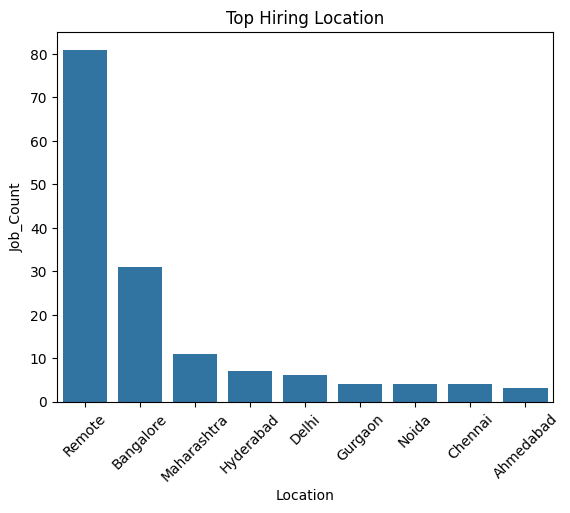

In [17]:
sns.barplot(data = location_demand,
                    x = 'Location' ,
                    y='Job_Count')
plt.xticks(rotation = 45)
plt.title('Top Hiring Location')
plt.show()

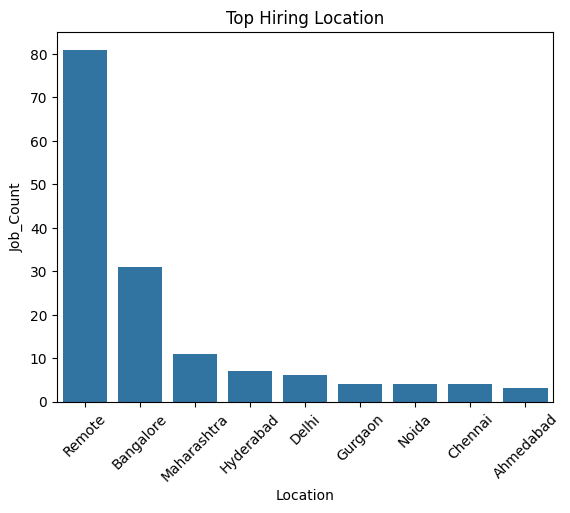

In [18]:
sns.barplot(data = location_demand,
                    x = 'Location' ,
                    y='Job_Count')
plt.xticks(rotation = 45)
plt.title('Top Hiring Location')
plt.show()

Text(0.5, 1.0, 'Location by salary')

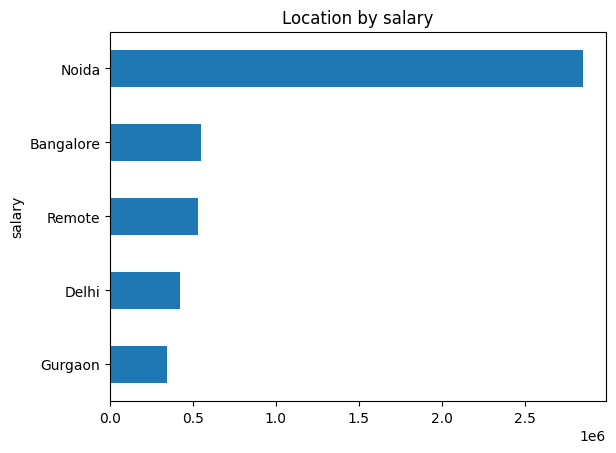

In [19]:
location_salary = ( 
            df_salary.groupby(["Location"])
            ["salary_avg"] 
            .median() 
            .sort_values()
            )
location_salary.plot(kind='barh')
plt.ylabel('salary')
plt.title('Location by salary')

In [20]:
remote_count = df_skill[df_skill['Location'] == 'Remote'].shape[0]
onsite_count = df_skill[df_skill['Location'] != 'Remote'].shape[0]

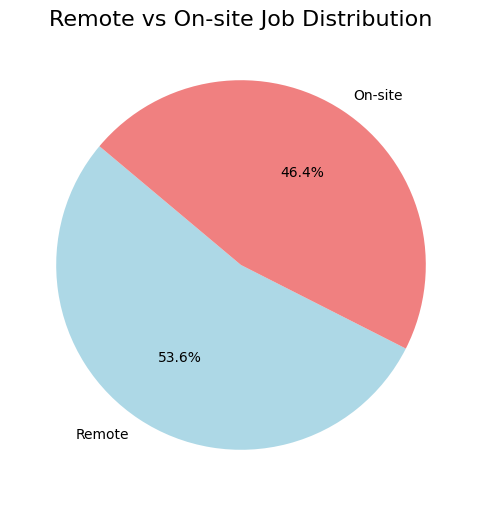

In [21]:
labels = ['Remote', 'On-site']
sizes = [remote_count, onsite_count]
colors = ['lightblue', 'lightcoral']
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Remote vs On-site Job Distribution', fontsize=16)
plt.show()

The dataset reveals a strong concentration of hiring in remote roles, followed by Bangalore and NCR regions. While salary differences across locations remain moderate, role distribution varies significantly, with technical roles more concentrated in major tech hubs.

In [25]:
pd.read_csv(r"d:/Startup/Project/ai-career-coach/data/processed/location_deemand.csv")

,Location,Job_Count,Percentage
0,Remote,81,53.642384
1,Bangalore,31,20.529801
2,Maharashtra,11,7.284768
3,Hyderabad,7,4.635762
4,Delhi,6,3.973510
5,Gurgaon,4,2.649007
6,Noida,4,2.649007
7,Chennai,4,2.649007
8,Ahmedabad,3,1.986755
